In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set_theme()

## Family 1: "What CEFR level is this word?"
  
* Source A (scraped): english_profile_scrape.csv → modified_scrap_data.csv

* Source B (teachers): word_pos_modified_data.csv 

In [ ]:
source_scraped_df = pd.read_csv('../data/raw/english_profile_cleaned.csv',keep_default_na=False, na_values=['']).assign(source='english_profile')

source_teachers_df = pd.read_csv("../data/raw/teacher_survey_cefr_ratings.csv").assign(source='teacher_survey')
source_teachers_df = source_teachers_df.rename(columns={'cefr_level_avg': 'cefr_int', 'cefr_level': 'cefr'})

family1_word_cefr = pd.concat([source_scraped_df, source_teachers_df], ignore_index=True)
family1_word_cefr['pos'] = family1_word_cefr['pos'].fillna('NA')
family1_word_cefr = family1_word_cefr.drop_duplicates(subset=['word', 'pos'], keep='first')
family1_word_cefr.head()

,word,pos,cefr_int,cefr,source
0,cattle,NA,3,B,english_profile
1,clothes,NA,1,A,english_profile
2,albeit,NA,6,C,english_profile
3,and,NA,1,A,english_profile
5,because,NA,1,A,english_profile


In [ ]:
print(f"Total unique words and associated POS: {family1_word_cefr.shape[0]} words")
print(f"Total unique POS tags: {family1_word_cefr['pos'].nunique()} types")

Total unique words and associated POS: 7620 words
Total unique POS tags: 14 types


Text(0.5, 1.0, 'Distribution of POS')

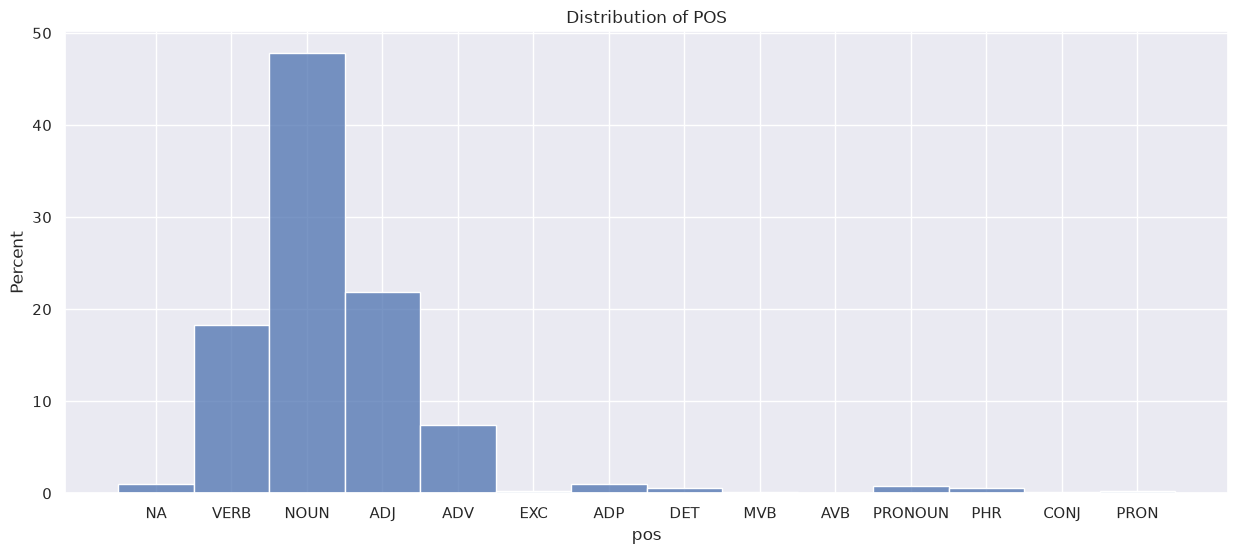

In [ ]:
plt.figure(figsize=(15,6))
sns.histplot(family1_word_cefr,x='pos',stat='percent')
plt.title('Distribution of POS')

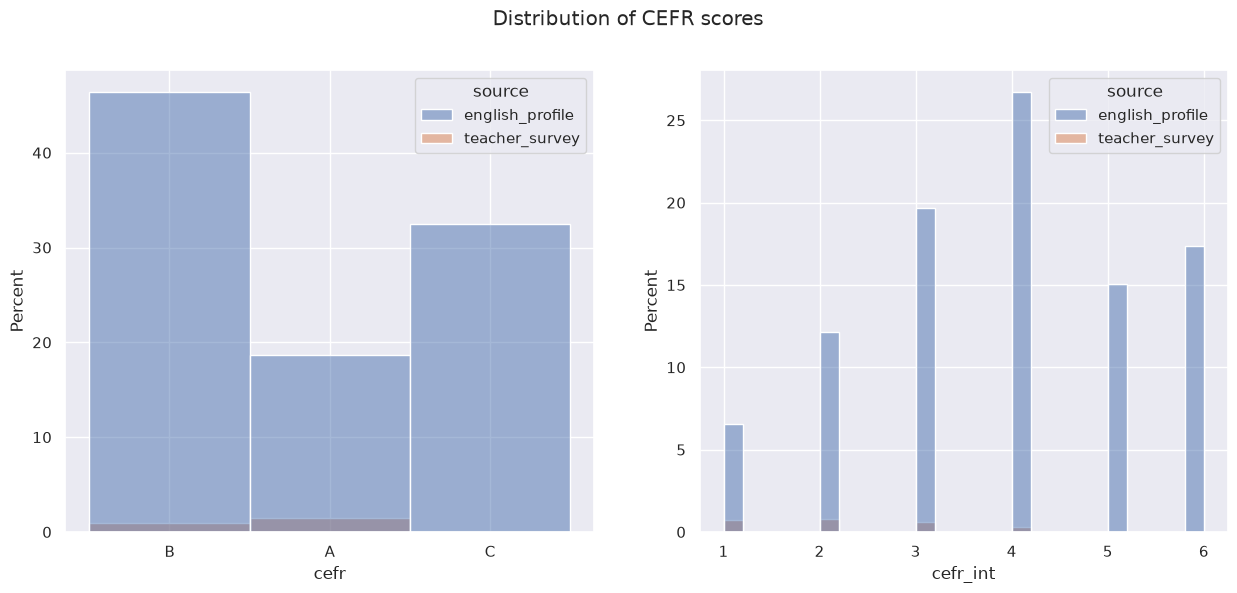

In [ ]:
# Distribution of CEFR level across different data sources

_,ax = plt.subplots(ncols=2,nrows=1,figsize=(15,6))

sns.histplot(family1_word_cefr,x='cefr',hue='source',stat='percent',ax=ax[0])
sns.histplot(family1_word_cefr,x='cefr_int',hue='source',stat='percent',ax=ax[1])
plt.suptitle('Distribution of CEFR scores')
plt.show()

## Family 2: "What are the synonyms for this word?"

* Source A (a synonym-finder scraper)
* Source B (a thesaurus scraper)

In [51]:
import json

with open('../data/raw/pos_acronym_map.json','r') as file:
    acronym_map = json.load(file)  

acronym_map

{'ADJ': 'aj',
 'ADV': 'av',
 'CONJ': 'cj',
 'DET': 'dt',
 'NOUN': 'n',
 'VERB': 'v',
 'PRON': 'pn',
 'ADP': 'pp',
 'nan': 'na'}

In [ ]:
source_synonyms_site_scrape = pd.read_csv("../data/raw/synonyms_scrape.csv")
source_thesarus_site_scrape = pd.read_csv("../data/raw/thesaurus_scrape.csv")


source_synonyms_site_scrape = source_synonyms_site_scrape.rename(columns={"Word":"word","Synonyms":"synonym_list"})
source_thesarus_site_scrape = source_thesarus_site_scrape.rename(columns={"Word":"word","Synonyms":"synonym_list"})


source_synonyms_site_scrape["synonym_list"] = source_synonyms_site_scrape["synonym_list"].apply(ast.literal_eval)
source_thesarus_site_scrape["synonym_list"] = source_thesarus_site_scrape["synonym_list"].apply(ast.literal_eval)
source_thesarus_site_scrape[['word','pos']] = source_thesarus_site_scrape['word'].str.rsplit(n=1,pat='_',expand=True)
full_pos_map = {v: k for k, v in acronym_map.items()}
source_thesarus_site_scrape['pos'] = source_thesarus_site_scrape['pos'].map(full_pos_map)

family2_word_synonyms = pd.merge(source_synonyms_site_scrape, source_thesarus_site_scrape, on='word', how='outer', suffixes=('_syn', '_thes'))
family2_word_synonyms.head()

,word,synonym_list_syn,synonym_list_thes,pos
0,AIRMAN,"[aviator, corporal, pilot, flier]",NaN,NaN
1,ANOther,"[other, latest, last, further, a]","[a different person, addition, one more, someo...",NOUN
2,ARTHUR,"[artur, arthure, arturo]",NaN,NaN
3,AWE,"[veneration, admiration, glare, reverence, daz...","[admiration, apprehension, astonishment, const...",NOUN
4,Albert,"[alberto, elbert, alberts, hugh]",NaN,NaN


In [ ]:
# combine synonyms list
def combine_lists(row):
    a = row['synonym_list_syn'] if isinstance(row['synonym_list_syn'], list) else []
    b = row['synonym_list_thes'] if isinstance(row['synonym_list_thes'], list) else []
    return a + b

family2_word_synonyms['synonym_list'] = family2_word_synonyms.apply(combine_lists,axis=1)
family2_word_synonyms.head()

,word,synonym_list_syn,synonym_list_thes,pos,synonym_list
0,AIRMAN,"[aviator, corporal, pilot, flier]",NaN,NaN,"[aviator, corporal, pilot, flier]"
1,ANOther,"[other, latest, last, further, a]","[a different person, addition, one more, someo...",NOUN,"[other, latest, last, further, a, a different ..."
2,ARTHUR,"[artur, arthure, arturo]",NaN,NaN,"[artur, arthure, arturo]"
3,AWE,"[veneration, admiration, glare, reverence, daz...","[admiration, apprehension, astonishment, const...",NOUN,"[veneration, admiration, glare, reverence, daz..."
4,Albert,"[alberto, elbert, alberts, hugh]",NaN,NaN,"[alberto, elbert, alberts, hugh]"


In [ ]:
# Add synonyms list to combined dataset
synonym_word_pos_df = family1_word_cefr.merge(family2_word_synonyms[['word', 'pos', 'synonym_list']], on=['word', 'pos'], how='left')
synonym_word_pos_df.head()

,word,pos,cefr_int,cefr,source,synonym_list
0,cattle,NA,3,B,english_profile,NaN
1,clothes,NA,1,A,english_profile,NaN
2,albeit,NA,6,C,english_profile,NaN
3,and,NA,1,A,english_profile,NaN
4,because,NA,1,A,english_profile,NaN


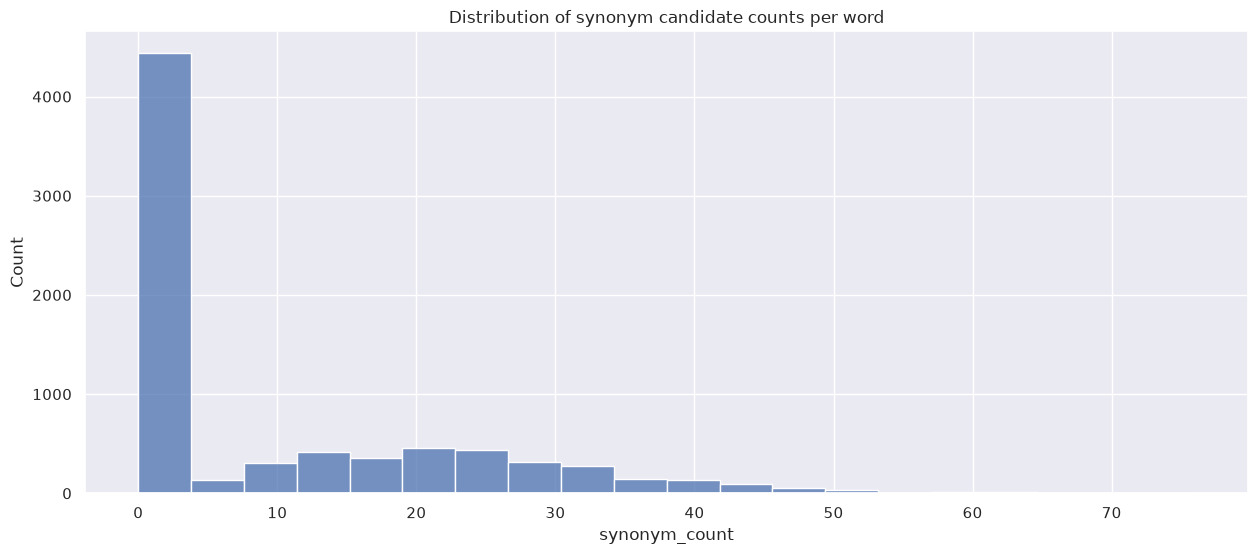

In [ ]:
synonym_word_pos_df['synonym_count'] = synonym_word_pos_df['synonym_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)

plt.figure(figsize=(15,6))
sns.histplot(synonym_word_pos_df, x='synonym_count', bins=20)
plt.title('Distribution of synonym candidate counts per word')
plt.show()

In [ ]:
candidates_df = (synonym_word_pos_df[['word', 'pos', 'synonym_list']]
                  .explode('synonym_list')
                  .dropna(subset=['synonym_list'])
                  .rename(columns={'word': 'original_word', 'synonym_list': 'candidate'}))

candidates_with_cefr = candidates_df.merge(
    family1_word_cefr[['word', 'pos', 'cefr']].rename(columns={'word': 'candidate'}),
    on=['candidate', 'pos'], how='inner'
)

In [73]:
candidates_with_cefr.head()

,original_word,pos,candidate,cefr
0,advertisement,NOUN,advertising,B
1,advertisement,NOUN,announcement,B
2,advertisement,NOUN,publicity,B
3,advertisement,NOUN,ad,B
4,advertisement,NOUN,advert,B


In [ ]:
print(f"Total words and associated POS: {candidates_with_cefr.shape[0]} words")
print(f"Total unique words: {candidates_with_cefr['original_word'].nunique()} words")

total_candidate_words_with_cefr = (candidates_with_cefr['candidate'].nunique()/family1_word_cefr['word'].nunique()) * 100
total_words_with_synonym_and_cefr = (candidates_with_cefr['original_word'].nunique()/family1_word_cefr['word'].nunique()) * 100
print(f"Total candidate/synonym words that have a CEFR level: {total_candidate_words_with_cefr:.2f}%")
print(f"Total words that have a synonym and a valid CEFR level: {total_words_with_synonym_and_cefr:.2f}%")

Total words and associated POS: 32962 words
Total unique words: 2901 words
Total candidate/synonym words that have a CEFR level: 77.27%
Total words that have a synonym and a valid CEFR level: 44.14%


## Family 3: "What English words exist, and what's their part of speech?"

> Part of Speech (POS) for available english words

In [ ]:
family3_vocabulary = pd.read_json('../data/raw/all_english_words.json', typ='series').index.to_series(name='eng_words').reset_index(drop=True)
family3_tagged = pd.read_csv('../data/processed/all_english_words_tagged.csv',keep_default_na=False, na_values=[''])  # already exists -- create_word_dataset.py's output

print(f"raw vocabulary: {len(family3_vocabulary)} words")
print(f"already-tagged (processed): {len(family3_tagged)} words")
print(f"same word set: {set(family3_vocabulary) == set(family3_tagged['eng_words'])}")

family3_tagged['pos_tag'].value_counts()

raw vocabulary: 370100 words
already-tagged (processed): 370100 words
same word set: True


pos_tag
NOUN    279502
ADJ      39572
VERB     33804
ADV      17034
CONJ        96
DET         32
PRON        22
Name: count, dtype: int64

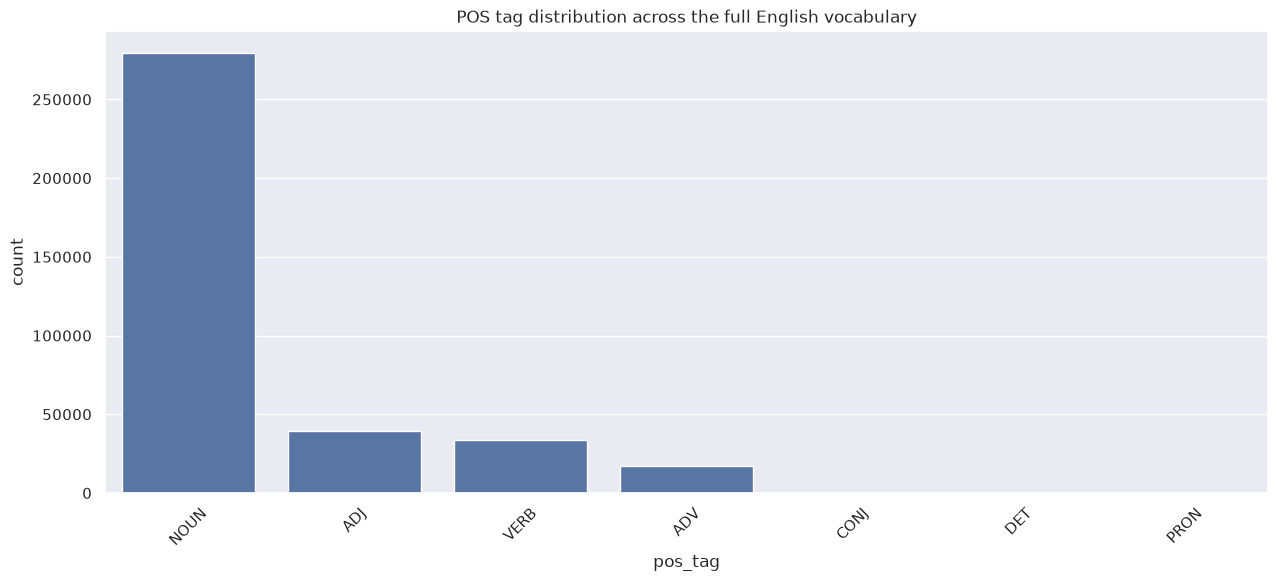

In [89]:
## Family 3
plt.figure(figsize=(15,6))
sns.countplot(data=family3_tagged, x='pos_tag', order=family3_tagged['pos_tag'].value_counts().index)
plt.title('POS tag distribution across the full English vocabulary')
plt.xticks(rotation=45)
plt.show()